# Guided Numeric Exploration — Gold Price Analysis (Ticker GOLD)
_Daily OHLCV for Yahoo ticker GOLD — not the spot/macro panel the data card describes_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [shakhnoza12/gold-price-analysis-20002026](https://www.kaggle.com/datasets/shakhnoza12/gold-price-analysis-20002026)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Price and Volume Univariate](#Univariate)** <br>
**4. [Returns, Volatility, Drawdowns](#Returns)** <br>
**5. [Calendar Patterns](#Calendar)** <br>
**6. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
The Kaggle data card describes **spot gold USD** plus macro factors (DXY, CPI, Fed funds, oil, SPX, BTC, …) from 2000–2026. **The CSV does not match that promise.**

What we actually have: Yahoo-style multi-header OHLCV for ticker **`GOLD`** (equity/ETF-scale prices, roughly single-digit to ~$45 Close), daily from **2014-03-17 to 2025-12-31**, with no macro columns. This notebook analyzes that equity series honestly and flags the mismatch.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data — Yahoo multi-header GOLD equity OHLCV
CSV_BASENAME = "gold_stock.csv"
KAGGLE_SLUG = "shakhnoza12/gold-price-analysis-20002026"


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        hits = list(kaggle_root.rglob(CSV_BASENAME))
        assert hits, f"{CSV_BASENAME} not under /kaggle/input"
        return hits[0]
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    hits = list(root.rglob(CSV_BASENAME))
    assert hits, f"expected {CSV_BASENAME} under {root}"
    return hits[0]


def load_gold_ohlcv(path: Path) -> pd.DataFrame:
    """Parse Yahoo-export layout: Price col holds dates; rows 0-1 are Ticker/Date meta."""
    raw = pd.read_csv(path, low_memory=False)
    assert list(raw.columns) == ["Price", "Close", "High", "Low", "Open", "Volume"], list(raw.columns)
    assert raw.iloc[0]["Price"] == "Ticker", raw.iloc[0].to_dict()
    ticker = str(raw.iloc[0]["Close"])
    assert ticker == "GOLD", f"expected ticker GOLD, got {ticker}"
    body = raw.iloc[2:].copy()  # skip Ticker + Date meta rows
    out = pd.DataFrame({
        "Date": pd.to_datetime(body["Price"], errors="coerce"),
        "Close": pd.to_numeric(body["Close"], errors="coerce"),
        "High": pd.to_numeric(body["High"], errors="coerce"),
        "Low": pd.to_numeric(body["Low"], errors="coerce"),
        "Open": pd.to_numeric(body["Open"], errors="coerce"),
        "Volume": pd.to_numeric(body["Volume"], errors="coerce"),
    })
    out = out.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)
    assert len(out) > 2000, len(out)
    # Equity/ETF scale sanity — spot bullion would sit far above this median
    med = float(out["Close"].median())
    assert med < 200, f"median Close={med} looks like bullion/spot, not ticker GOLD equity scale"
    assert out["Date"].min() >= pd.Timestamp("2014-01-01")
    assert out["Date"].max() <= pd.Timestamp("2026-12-31")
    out["ticker"] = ticker
    return out


csv_path = resolve_csv_path()
print("CSV:", csv_path)
df = load_gold_ohlcv(csv_path)
df["ret"] = df["Close"].pct_change()
df["log_ret"] = np.log(df["Close"]).diff()
df["year"] = df["Date"].dt.year

unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
print("Ticker:", df["ticker"].iloc[0])
print("Date range:", df["Date"].min().date(), "→", df["Date"].max().date())
print("Rows:", len(df))
print("Close median/min/max:", round(df["Close"].median(), 2), round(df["Close"].min(), 2), round(df["Close"].max(), 2))
print("Macro columns present?", any(c.lower() in {"usd", "cpi", "vix", "spx", "bitcoin"} for c in df.columns))


Ticker: GOLD
Date range: 2014-03-17 → 2025-12-31
Rows: 2968
Close median/min/max: 6.96 2.95 44.81
Macro columns present? False


**Code Explanation and Reasoning:** <br>
The loader skips Yahoo meta rows, coerces OHLCV, and asserts an equity-scale Close median (<200) so we do not silently treat this as spot gold. Missing macro factors are noted in the printout.


In [3]:
df.sample(5, random_state=7)


,Date,Close,High,Low,Open,Volume,ticker,ret,log_ret,year
2942,2025-11-24,25.820429,26.256717,25.612199,26.217056,242900,GOLD,-0.015129,-0.015244,2025
2630,2024-08-27,34.983879,35.117587,34.258031,35.088936,264000,GOLD,-0.003807,-0.003815,2024
456,2016-01-06,6.506154,7.115318,6.362695,7.028809,297000,GOLD,-0.081425,-0.084932,2016
1512,2020-03-18,3.302447,3.584547,3.234744,3.426571,20800,GOLD,-0.002273,-0.002275,2020
1371,2019-08-26,5.382463,5.442644,5.314759,5.442644,4400,GOLD,0.008457,0.008421,2019


In [4]:
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]))
df[["Close", "High", "Low", "Open", "Volume", "ret"]].describe().T.round(3)


,Column,Unique,Null
0,Date,2968,0
1,Close,2467,0
2,High,2917,0
3,Low,2938,0
4,Open,2950,0
5,Volume,1495,0
6,ticker,1,0
7,ret,2888,1
8,log_ret,2888,1
9,year,12,0


,count,mean,std,min,25%,50%,75%,max
Close,2968.0,14.743,11.670,2.953,4.830,6.963,26.291,44.811
High,2968.0,15.043,11.902,3.020,4.920,7.068,26.766,45.260
Low,2968.0,14.445,11.436,2.810,4.742,6.800,25.791,44.086
Open,2968.0,14.754,11.677,2.972,4.830,6.924,26.344,44.811
Volume,2968.0,135577.291,178762.414,0.000,18200.000,72800.000,190450.000,2739600.000
ret,2967.0,0.001,0.028,-0.175,-0.013,0.000,0.014,0.272


**Interpretation** <br>
This is a daily equity OHLCV panel for ticker GOLD starting 2014, not a 2000–2026 spot/macro dataset. Analyses below are about this ticker's market path.


# **3. Price and Volume Univariate:** <a id="Univariate"></a>


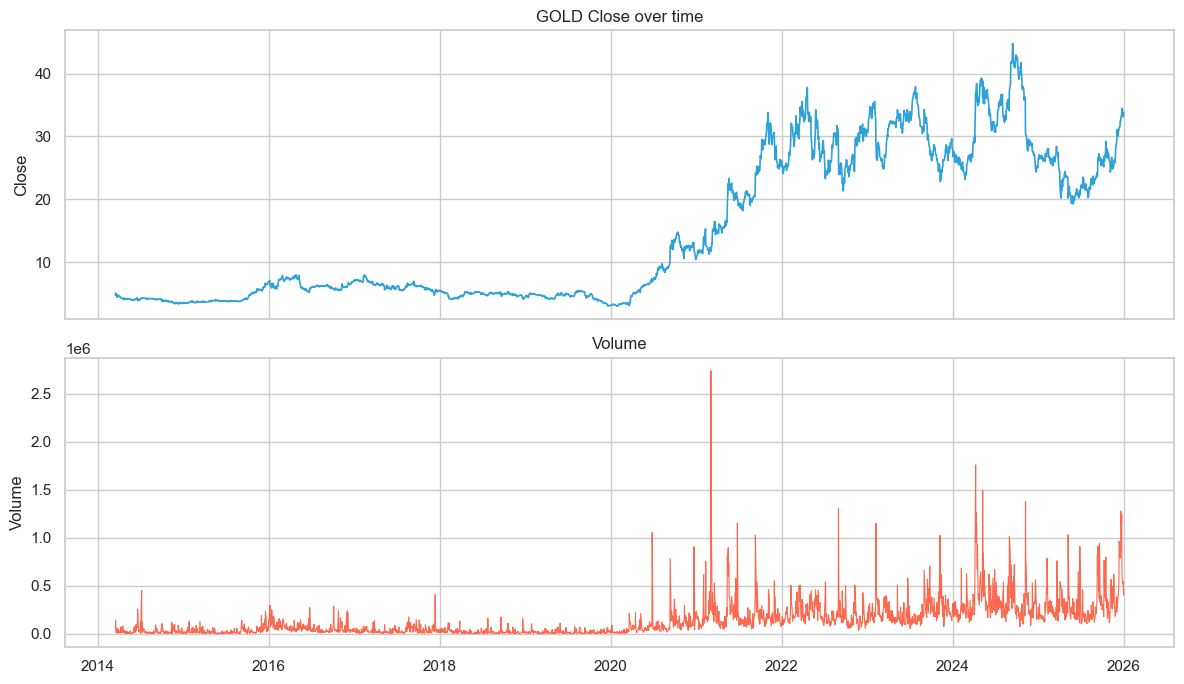

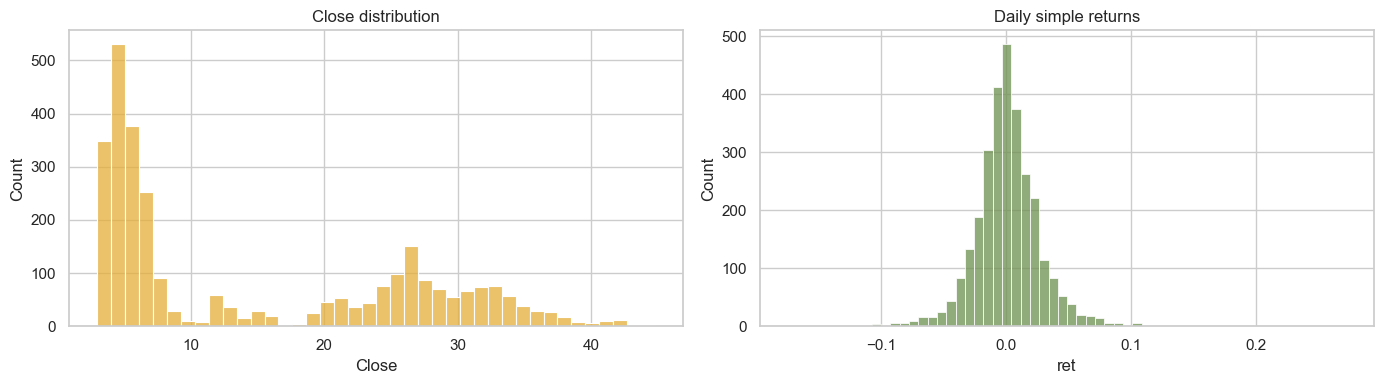

In [5]:
f, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax[0].plot(df["Date"], df["Close"], color="#30a2da", lw=1.2)
ax[0].set_title("GOLD Close over time")
ax[0].set_ylabel("Close")
ax[1].plot(df["Date"], df["Volume"], color="#fc4f30", lw=0.8, alpha=0.85)
ax[1].set_title("Volume")
ax[1].set_ylabel("Volume")
plt.tight_layout()
plt.show()

f, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["Close"], bins=40, ax=ax[0], color="#e5ae38")
ax[0].set_title("Close distribution")
sns.histplot(df["ret"].dropna(), bins=60, ax=ax[1], color="#6d904f")
ax[1].set_title("Daily simple returns")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Level chart shows regimes (flat vs trending). Volume spikes often mark regime shifts or news. Return histogram should be roughly centered near zero with fat tails if equity-like.


# **4. Returns, Volatility, Drawdowns:** <a id="Returns"></a>


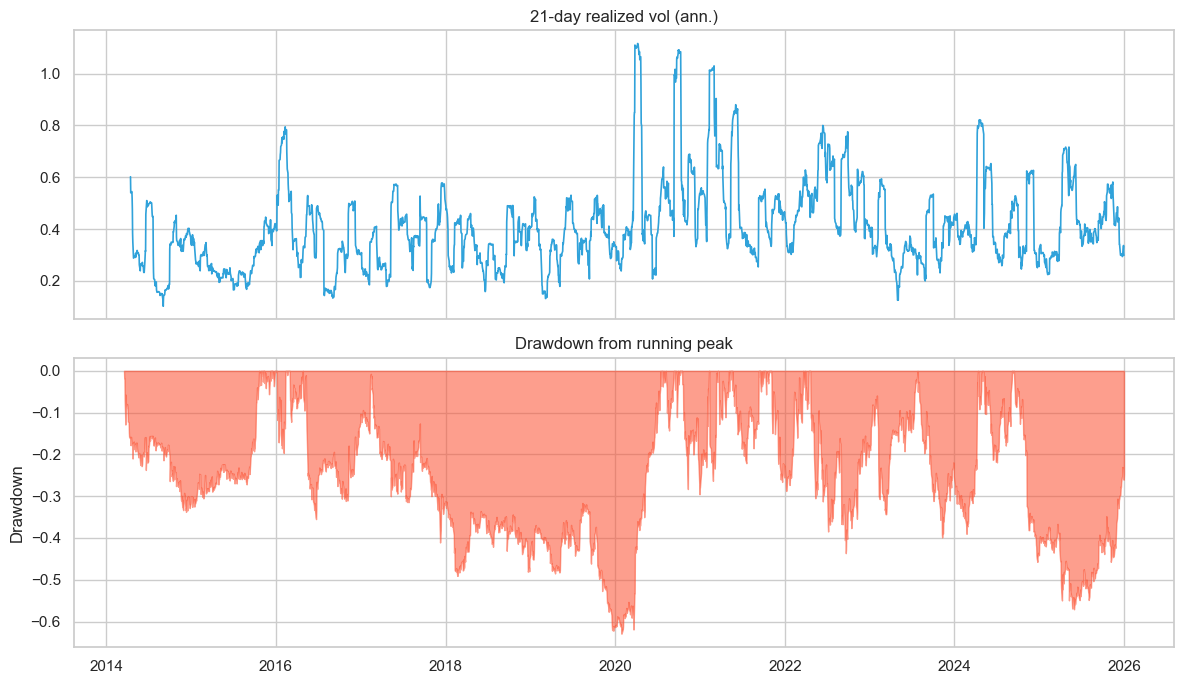

Worst drawdown: -0.629
Mean daily ret / ann. vol: 0.00105 0.443


In [6]:
work = df.dropna(subset=["ret"]).copy()
work["vol_21"] = work["ret"].rolling(21).std() * np.sqrt(252)
work["cummax"] = work["Close"].cummax()
work["drawdown"] = work["Close"] / work["cummax"] - 1

f, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax[0].plot(work["Date"], work["vol_21"], color="#30a2da", lw=1.2)
ax[0].set_title("21-day realized vol (ann.)")
ax[1].fill_between(work["Date"], work["drawdown"], 0, color="#fc4f30", alpha=0.55)
ax[1].set_title("Drawdown from running peak")
ax[1].set_ylabel("Drawdown")
plt.tight_layout()
plt.show()

print("Worst drawdown:", round(work["drawdown"].min(), 3))
print("Mean daily ret / ann. vol:",
      round(work["ret"].mean(), 5),
      round(work["ret"].std() * np.sqrt(252), 3))


**How to Interpret:** <br>
Rolling vol marks stress regimes. Drawdown depth shows how far Close fell from its prior peak — useful for risk context, not a trading signal by itself.


# **5. Calendar Patterns:** <a id="Calendar"></a>

Seasonality here means average daily-return behavior by **calendar year**, **month / quarter**, and **weekday** — descriptive patterns in ticker GOLD equity returns, not a trading rule.


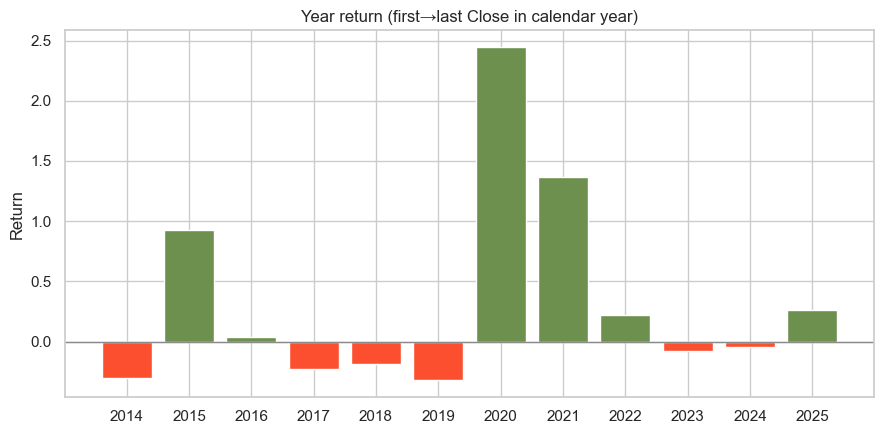

,first,last,year_return
year,,,
2014,5.049,3.532,-0.300
2015,3.532,6.795,0.924
2016,6.895,7.140,0.035
2017,7.074,5.471,-0.227
2018,5.463,4.435,-0.188
2019,4.574,3.111,-0.320
2020,3.081,10.618,2.446
2021,11.041,26.150,1.369
2022,25.341,30.972,0.222


In [7]:
# Year-by-year total return from first to last close in year
yr = (
    work.groupby("year")["Close"]
    .agg(first="first", last="last")
    .assign(year_return=lambda d: d["last"] / d["first"] - 1)
)
f, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#6d904f" if v >= 0 else "#fc4f30" for v in yr["year_return"]]
ax.bar(yr.index.astype(str), yr["year_return"], color=colors)
ax.axhline(0, color="#8b8b8b", lw=1)
ax.set_title("Year return (first→last Close in calendar year)")
ax.set_ylabel("Return")
plt.tight_layout()
plt.show()
display(yr.round(3))


**How to Interpret:** <br>
Calendar-year bars summarize path-dependent annual performance of ticker GOLD. Partial first/last years can distort — check row counts per year if a bar looks extreme. Next we slice the *same* daily returns by month, quarter, and weekday to see whether any intra-year or day-of-week tilt survives averaging.


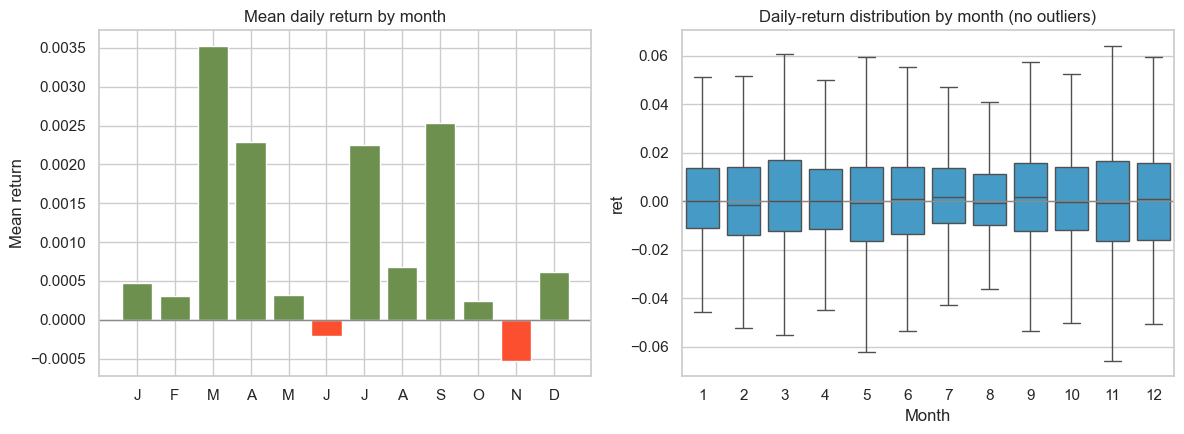

,mean_ret,median_ret,std_ret,n,mean_ret_bps
month,,,,,
1,0.00047,0.00000,0.0234,222,4.69
2,0.00030,-0.00139,0.0321,211,3.02
3,0.00352,0.00000,0.0335,251,35.22
4,0.00228,0.00014,0.0262,248,22.83
5,0.00032,-0.00078,0.0327,254,3.16
6,-0.00021,0.00083,0.0258,253,-2.07
7,0.00225,0.00156,0.0225,254,22.51
8,0.00067,-0.00085,0.0218,265,6.74
9,0.00254,0.00182,0.0338,246,25.39


Best / worst month (mean daily ret): 3 0.00352 | 11 -0.00052


In [8]:
# Month-of-year seasonality (average daily return + distribution)
cal = work.copy()
cal["month"] = cal["Date"].dt.month
cal["quarter"] = cal["Date"].dt.quarter
cal["weekday"] = cal["Date"].dt.dayofweek  # Mon=0 … Fri=4
cal["weekday_name"] = cal["Date"].dt.day_name()
assert set(cal["weekday"].unique()) <= set(range(5)), "expected Mon–Fri only for equity session"

month_stats = (
    cal.groupby("month")["ret"]
    .agg(mean_ret="mean", median_ret="median", std_ret="std", n="count")
    .reindex(range(1, 13))
)
assert month_stats["n"].min() > 100, month_stats["n"].to_dict()

f, ax = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ["#6d904f" if v >= 0 else "#fc4f30" for v in month_stats["mean_ret"]]
ax[0].bar(month_stats.index, month_stats["mean_ret"], color=colors)
ax[0].axhline(0, color="#8b8b8b", lw=1)
ax[0].set_xticks(range(1, 13))
ax[0].set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax[0].set_title("Mean daily return by month")
ax[0].set_ylabel("Mean return")

sns.boxplot(data=cal, x="month", y="ret", ax=ax[1], color="#30a2da", showfliers=False)
ax[1].axhline(0, color="#8b8b8b", lw=1)
ax[1].set_title("Daily-return distribution by month (no outliers)")
ax[1].set_xlabel("Month")
plt.tight_layout()
plt.show()

display(month_stats.assign(
    mean_ret_bps=lambda d: d["mean_ret"] * 1e4,
).round({"mean_ret": 5, "median_ret": 5, "std_ret": 4, "mean_ret_bps": 2}))
print("Best / worst month (mean daily ret):",
      int(month_stats["mean_ret"].idxmax()),
      round(month_stats["mean_ret"].max(), 5),
      "|",
      int(month_stats["mean_ret"].idxmin()),
      round(month_stats["mean_ret"].min(), 5))


**How to Interpret:** <br>
Month bars answer “is there a calendar-month tilt in average daily returns?” Boxplots show whether a strong mean is driven by a shift of the whole distribution or a few fat days (outliers hidden here). Large month gaps with overlapping boxes are usually noise — treat this as exploratory, not a seasonal trading edge.


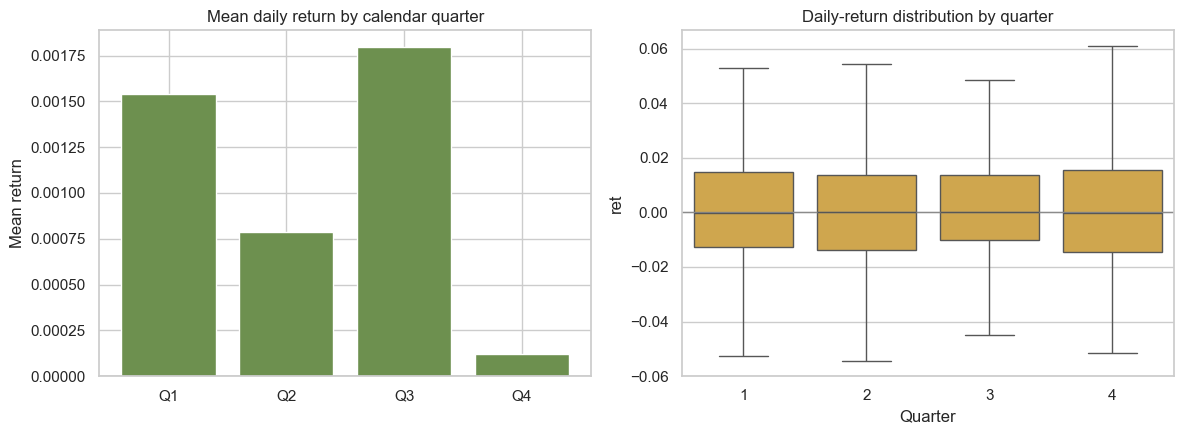

,mean_ret,median_ret,std_ret,n,approx_quarter_ret,mean_ret_bps
quarter,,,,,,
1,0.00154,-0.00039,0.03014,684,0.10165,15.37851
2,0.00079,0.00000,0.02840,755,0.05079,7.86671
3,0.00180,0.00000,0.02646,765,0.11976,17.97084
4,0.00012,-0.00027,0.02673,763,0.00774,1.22452


Strongest quarter (mean daily ret): Q3 0.0018


In [9]:
# Quarterly seasonality — average daily return and quarter total return path
q_stats = (
    cal.groupby("quarter")["ret"]
    .agg(mean_ret="mean", median_ret="median", std_ret="std", n="count")
    .reindex(range(1, 5))
)
assert q_stats["n"].min() > 400, q_stats["n"].to_dict()

# Compound average path: mean daily return × typical trading days per quarter (~63)
q_stats = q_stats.assign(approx_quarter_ret=lambda d: (1 + d["mean_ret"]) ** 63 - 1)

f, ax = plt.subplots(1, 2, figsize=(12, 4.5))
q_colors = ["#6d904f" if v >= 0 else "#fc4f30" for v in q_stats["mean_ret"]]
ax[0].bar(q_stats.index.astype(str).map(lambda s: f"Q{s}"), q_stats["mean_ret"], color=q_colors)
ax[0].axhline(0, color="#8b8b8b", lw=1)
ax[0].set_title("Mean daily return by calendar quarter")
ax[0].set_ylabel("Mean return")

sns.boxplot(data=cal, x="quarter", y="ret", ax=ax[1], color="#e5ae38", showfliers=False)
ax[1].axhline(0, color="#8b8b8b", lw=1)
ax[1].set_title("Daily-return distribution by quarter")
ax[1].set_xlabel("Quarter")
plt.tight_layout()
plt.show()

display(q_stats.assign(mean_ret_bps=lambda d: d["mean_ret"] * 1e4).round(5))
print("Strongest quarter (mean daily ret): Q{}".format(int(q_stats["mean_ret"].idxmax())),
      round(q_stats["mean_ret"].max(), 5))


**How to Interpret:** <br>
Quarters compress the month view into four buckets. A Q1 vs Q4 gap in *mean daily* return of a few basis points can look large after compounding (~63 sessions), but the boxplots should still overlap heavily if the effect is weak. Compare with the year-return bars above — a few monster years (e.g. 2020–21) can dominate any seasonal average.


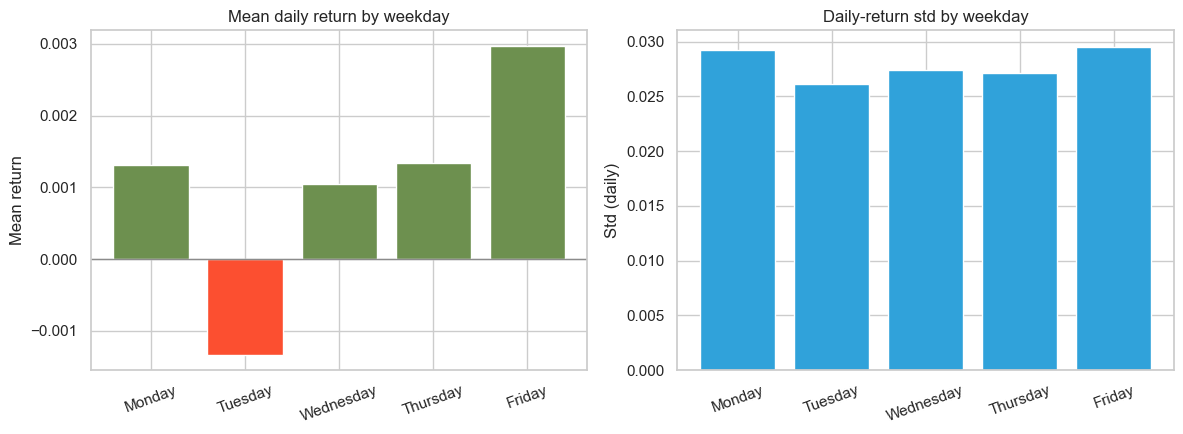

Kruskal–Wallis weekday returns: H=8.69, p=0.0692


,mean_ret,median_ret,std_ret,n,mean_ret_bps
weekday_name,,,,,
Monday,0.00131,-0.00091,0.02924,556,13.13304
Tuesday,-0.00133,-0.00180,0.02611,612,-13.30998
Wednesday,0.00104,0.00067,0.02740,609,10.43587
Thursday,0.00134,0.00000,0.02715,596,13.36374
Friday,0.00297,0.00072,0.02954,594,29.73700


Best / worst weekday (mean ret): Friday 0.00297 | Tuesday -0.00133


In [10]:
# Weekday seasonality — Mon–Fri mean return and realized vol
wd_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
wd_stats = (
    cal.groupby("weekday_name")["ret"]
    .agg(mean_ret="mean", median_ret="median", std_ret="std", n="count")
    .reindex(wd_order)
)
assert wd_stats["n"].notna().all(), wd_stats["n"].to_dict()
assert wd_stats["n"].min() > 400, wd_stats["n"].to_dict()

f, ax = plt.subplots(1, 2, figsize=(12, 4.5))
wd_colors = ["#6d904f" if v >= 0 else "#fc4f30" for v in wd_stats["mean_ret"]]
ax[0].bar(wd_stats.index, wd_stats["mean_ret"], color=wd_colors)
ax[0].axhline(0, color="#8b8b8b", lw=1)
ax[0].set_title("Mean daily return by weekday")
ax[0].set_ylabel("Mean return")
ax[0].tick_params(axis="x", rotation=20)

ax[1].bar(wd_stats.index, wd_stats["std_ret"], color="#30a2da")
ax[1].set_title("Daily-return std by weekday")
ax[1].set_ylabel("Std (daily)")
ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

# Kruskal–Wallis: do weekday return distributions differ? (nonparametric, exploratory)
kw_stat, kw_p = stats.kruskal(
    *[cal.loc[cal["weekday_name"] == d, "ret"].values for d in wd_order]
)
print(f"Kruskal–Wallis weekday returns: H={kw_stat:.2f}, p={kw_p:.4f}")
display(wd_stats.assign(mean_ret_bps=lambda d: d["mean_ret"] * 1e4).round(5))
print("Best / worst weekday (mean ret):",
      wd_stats["mean_ret"].idxmax(),
      round(wd_stats["mean_ret"].max(), 5),
      "|",
      wd_stats["mean_ret"].idxmin(),
      round(wd_stats["mean_ret"].min(), 5))


**How to Interpret:** <br>
Weekday bars ask whether Monday–Friday mean returns or vol differ for GOLD. Equity sessions exclude weekends, so this is a five-bucket comparison only. A Kruskal–Wallis *p* above conventional thresholds means we cannot reject “same distribution across weekdays” — visual gaps may still be sampling noise. Vol bars matter as much as means: a day that is quieter but flat is a different story from a day that is both weak and noisy.


# **6. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
Daily OHLCV for Yahoo ticker GOLD (2014–2025), not the spot-gold + macro panel advertised on the card.

**Working takeaways:** <br>
- Parse Yahoo headers carefully; assert equity price scale.
- Returns/vol/drawdowns are the right EDA for this file.
- Calendar cuts (year / month / quarter / weekday) are descriptive seasonality checks — year totals swing hard; intra-year and weekday tilts need overlapping distributions and weak tests before calling them real.
- Do not invent DXY/CPI joins that are not in the CSV.

**Open follow-ups:** <br>
- If a true spot+macro table appears, rebuild correlations against rates/USD.
- Compare GOLD equity beta to a gold miner index or GLD.
- Bootstrap or year-holdout checks on month/weekday means to stress-test seasonality stability.
